# Notebook 02 — Degradation trajectories

Run the parametric degradation models and visualise how EIS spectra
evolve under each mode over time.

**Degradation modes implemented:**
1. **Oxidation** — IrO2 passivation layer grows; Rct rises linearly, Cdl falls.
2. **Evaporation** — IrO3 sublimation removes electrode mass; Rct rises exponentially, area shrinks.
3. **Combined** — weighted superposition of both.

**What this does not show:** temperature transients; bath chemistry coupling;
mechanical stress; real measurement noise characterisation.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from randles_model import moe_frequencies, nyquist_arrays, randles_impedance
from degradation_sim import (
    oxidation_trajectory,
    evaporation_trajectory,
    combined_trajectory,
    healthy_trajectory,
    RCT_FAILURE_MULTIPLIER,
)

In [2]:
freqs = moe_frequencies(n_per_decade=10)

ox  = oxidation_trajectory(n_steps=100, total_hours=500)
ev  = evaporation_trajectory(n_steps=100, total_hours=300)
com = combined_trajectory(n_steps=100, total_hours=400)

print(f"Oxidation   — failure at {ox.failure_hour:.0f} h")
print(f"Evaporation — failure at {ev.failure_hour:.0f} h")
print(f"Combined    — failure at {com.failure_hour:.0f} h")

Oxidation   — failure at 500 h
Evaporation — failure at 255 h
Combined    — failure at 360 h


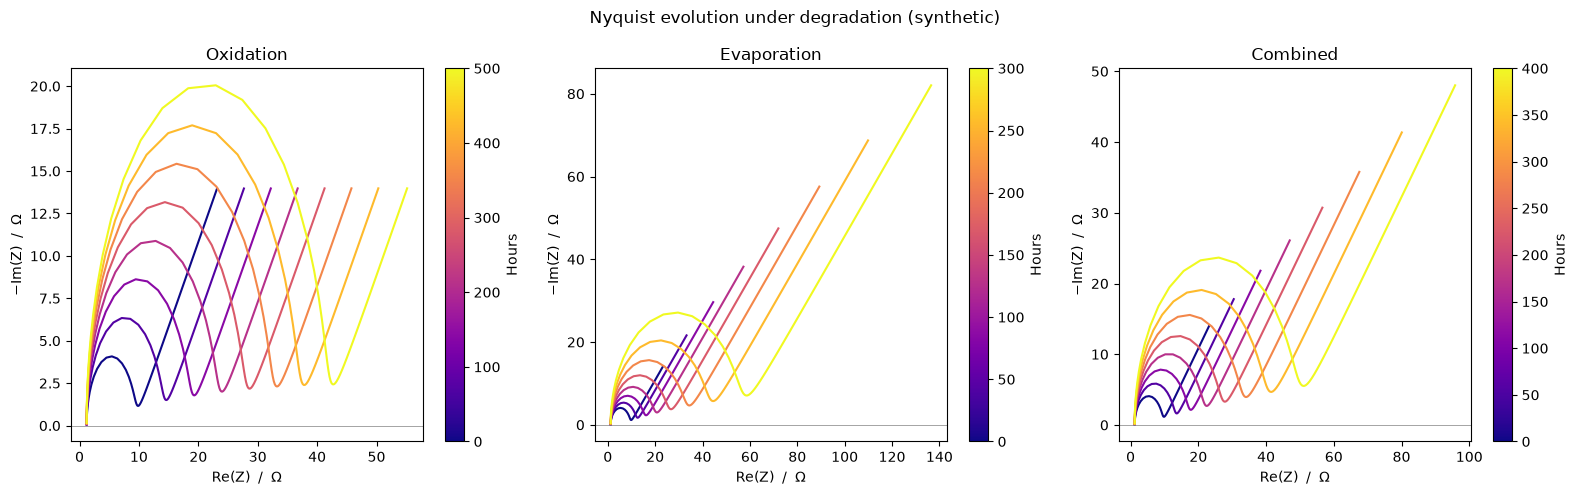

In [3]:
# ── Nyquist evolution for each degradation mode ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, scenario, title in zip(axes, [ox, ev, com], ['Oxidation', 'Evaporation', 'Combined']):
    cmap = cm.plasma
    n = len(scenario.params)
    indices = np.linspace(0, n - 1, 8, dtype=int)
    for i in indices:
        Z = randles_impedance(scenario.params[i], freqs)
        re, nim = nyquist_arrays(Z)
        color = cmap(i / (n - 1))
        label = f"{scenario.hours[i]:.0f} h"
        ax.plot(re, nim, color=color, lw=1.5, label=label)
    ax.set_xlabel('Re(Z)  /  Ω')
    ax.set_ylabel('−Im(Z)  /  Ω')
    ax.set_title(title)
    ax.axhline(0, color='grey', lw=0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, scenario.hours[-1]))
    plt.colorbar(sm, ax=ax, label='Hours')

fig.suptitle('Nyquist evolution under degradation (synthetic)', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/02-nyquist-evolution.png', dpi=150, bbox_inches='tight')
plt.show()

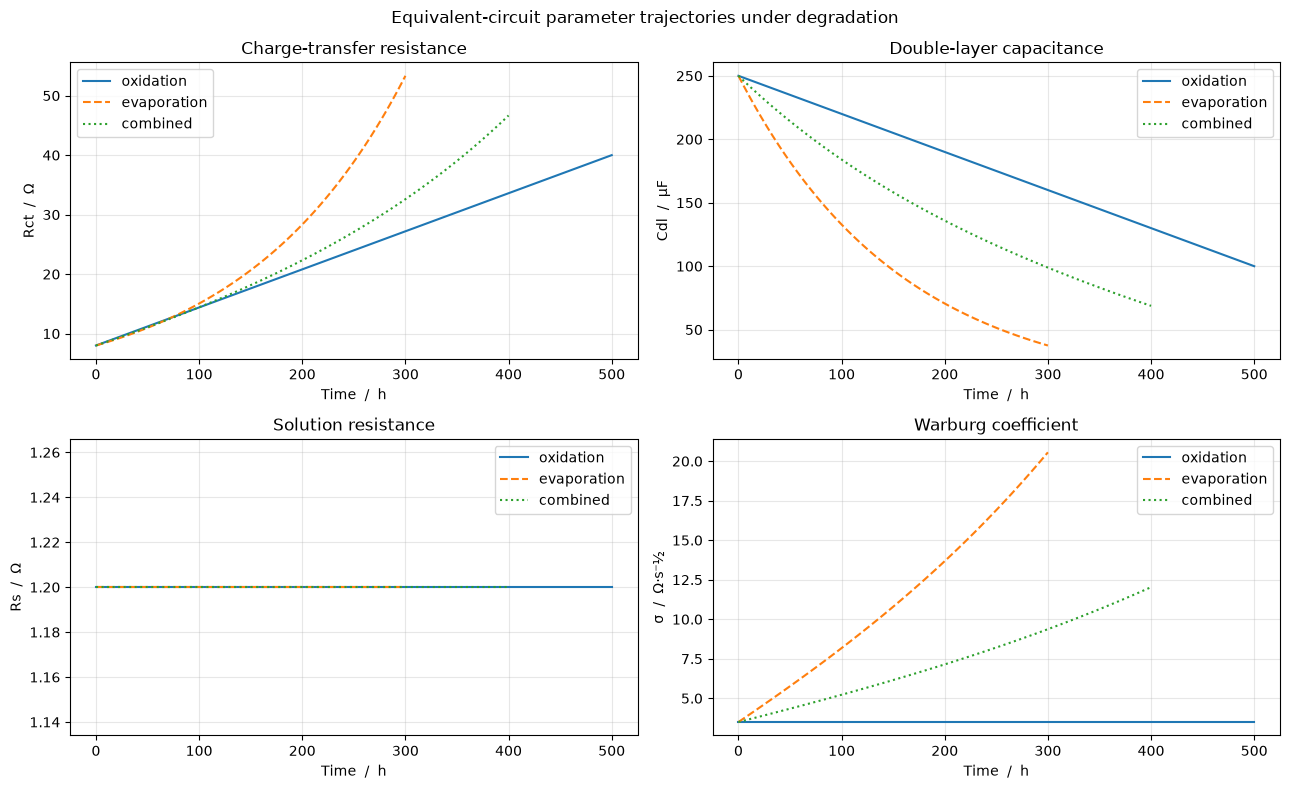

In [4]:
# ── Parameter trajectories over time ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for scenario, style in [(ox, '-'), (ev, '--'), (com, ':')]:
    label = scenario.name
    axes[0, 0].plot(scenario.hours, scenario.rct_series(), style, label=label)
    axes[0, 1].plot(scenario.hours, scenario.cdl_series() * 1e6, style, label=label)
    axes[1, 0].plot(scenario.hours, scenario.rs_series(), style, label=label)
    sigma_vals = [p.sigma for p in scenario.params]
    axes[1, 1].plot(scenario.hours, sigma_vals, style, label=label)

axes[0, 0].set_ylabel('Rct  /  Ω'); axes[0, 0].set_title('Charge-transfer resistance')
axes[0, 1].set_ylabel('Cdl  /  μF'); axes[0, 1].set_title('Double-layer capacitance')
axes[1, 0].set_ylabel('Rs  /  Ω'); axes[1, 0].set_title('Solution resistance')
axes[1, 1].set_ylabel('σ  /  Ω·s⁻½'); axes[1, 1].set_title('Warburg coefficient')

for ax in axes.ravel():
    ax.set_xlabel('Time  /  h')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Equivalent-circuit parameter trajectories under degradation', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/02-parameter-trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

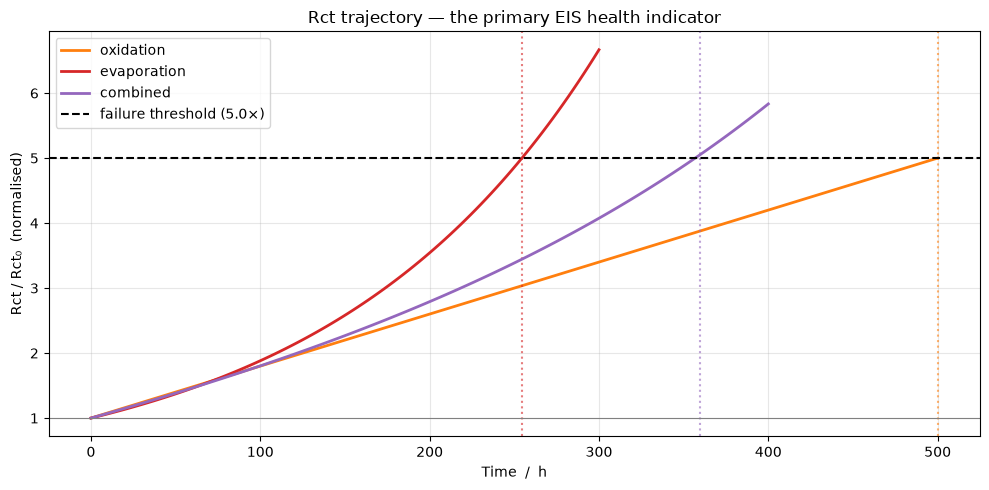

In [5]:
# ── Rct as the primary health indicator ───────────────────────────────────────
baseline_rct = ox.params[0].Rct

fig, ax = plt.subplots(figsize=(10, 5))
for scenario, col, label in [
    (ox, 'tab:orange', 'oxidation'),
    (ev, 'tab:red', 'evaporation'),
    (com, 'tab:purple', 'combined'),
]:
    rct_norm = scenario.rct_series() / baseline_rct
    ax.plot(scenario.hours, rct_norm, color=col, lw=2, label=label)
    if scenario.failure_hour:
        ax.axvline(scenario.failure_hour, color=col, ls=':', alpha=0.6)

ax.axhline(RCT_FAILURE_MULTIPLIER, color='black', ls='--', lw=1.5, label=f'failure threshold ({RCT_FAILURE_MULTIPLIER}×)')
ax.axhline(1.0, color='grey', ls='-', lw=0.8)
ax.set_xlabel('Time  /  h')
ax.set_ylabel('Rct / Rct₀  (normalised)')
ax.set_title('Rct trajectory — the primary EIS health indicator')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02-rct-trajectory.png', dpi=150, bbox_inches='tight')
plt.show()